### Dependencies

In [1]:
%pip install networkx
%pip install numpy
%pip install scikit-learn
%pip install matplotlib
%pip install scipy
%pip install torch
%pip install torch-geometric

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 8.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install --upgrade torch-geometric
%pip install --upgrade torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
    --------------------------------------- 2.4/113.8 MB 19.2 MB/s eta 0:00:06
   ---- ----------------------------------- 11.8/113.8 MB 35.2 MB/s eta 0:00:03
   -------- ------------------------------- 22.8/113.8 MB 42.5 MB/s eta 0:00:03
   ----------- ---------------------------- 33.8/113.8 MB 45.7 MB/s eta 0:00:02
   --------------- ------------------------ 43.8/113.8 MB 45.7 MB/s eta 0:00:02
   ------------------- -------------------- 56.6/113.8 MB 48.8 MB/s eta 0:00:02
   ----------------------- ---------------- 67.1/113.8 MB 49.2 MB/s eta 0:00:01
   ------------------------ --------------- 70.3/113.8 MB 45.2 MB/s eta 0:00:01
   -------------------------- ------------- 75.5/113.8 MB 43.4 MB/s eta 0:00:01
   ---------------------------- ----------- 80.2/113.8 MB 40.3 MB/s eta 0:00:01
   ------------------------------- -------- 89.7/113.8 MB 40.6 MB/s eta 0:00:01
   ----------------------------------- ---- 99.6/1


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import networkx as nx
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import LocalOutlierFactor
import copy
from scipy.io import loadmat
from torch_geometric.utils.convert import from_scipy_sparse_matrix
import torch
import torch_geometric
from sklearn.metrics import roc_auc_score

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import warnings
warnings.filterwarnings('default')

### Exercise 1

In [7]:
def ex1_1(num_maximum_edges=None):
    astro_ph_file = open('ca-AstroPh.txt', 'r')

    edge_weights = dict()
    for idx, line in enumerate(astro_ph_file):
        node_0, node_1 = line.strip().split()
        node_0 = int(node_0)
        node_1 = int(node_1)

        if node_0 > node_1:
            aux = node_0
            node_0 = node_1
            node_1 = aux

        edge = (node_0, node_1)
        if edge not in edge_weights:
            edge_weights[edge] = 0
        edge_weights[edge] += 1

        if num_maximum_edges is not None:
            if idx == num_maximum_edges - 1:
                break

    astro_ph_file.close()

    G = nx.Graph()
    for edge, weight in edge_weights.items():
        node_0, node_1 = edge
        G.add_edge(node_0, node_1, weight=weight)

    print(f'Number of Nodes: {G.number_of_nodes()}')
    print(f'Number of Edges: {G.number_of_edges()}')

    return G


graph_ex1_1 = ex1_1(num_maximum_edges=None)

Number of Nodes: 18772
Number of Edges: 198110


In [8]:
def ex1_2(graph):
    
    for node in graph.nodes():
        neighbors = list(graph.neighbors(node))
        egonet = graph.subgraph([node] + neighbors)

        egonet_num_neighbors = len(neighbors)
        egonet_num_edges = egonet.number_of_edges()
        egonet_total_weight = sum([data['weight'] for _, _, data in egonet.edges(data=True)])

        if egonet_num_neighbors == 0:
            principal_eigen_value = 0.0
        else:
            adjacency_matrix = nx.adjacency_matrix(egonet, weight='weight').todense()
            eigen_values = np.linalg.eigvals(adjacency_matrix)
            principal_eigen_value = eigen_values[np.argmax(np.real(eigen_values))].real

        graph.nodes[node]['egonet_num_neighbors'] = egonet_num_neighbors
        graph.nodes[node]['egonet_num_edges'] = egonet_num_edges
        graph.nodes[node]['egonet_total_weight'] = egonet_total_weight
        graph.nodes[node]['egonet_principal_eigen_value'] = principal_eigen_value

    return graph


graph_ex1_2 = ex1_2(graph_ex1_1)

In [9]:
def ex1_3(graph):

    nodes = np.array(list(graph.nodes()))
    egonet_num_neighbors = np.array([graph.nodes[node]['egonet_num_neighbors'] for node in graph.nodes()])
    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])

    filter_mask = ((0 < egonet_num_neighbors) & (0 < egonet_num_edges))
    nodes = nodes[filter_mask]
    egonet_num_neighbors = egonet_num_neighbors[filter_mask]
    egonet_num_edges = egonet_num_edges[filter_mask]

    X = np.log(egonet_num_neighbors).reshape(-1, 1)
    Y = np.log(egonet_num_edges).reshape(-1, 1)

    linear_regression = LinearRegression()
    linear_regression.fit(X, Y)

    C = np.exp(linear_regression.intercept_[0])
    theta = linear_regression.coef_[0][0]

    print(f'Linear Regression: C={C} theta={theta}')

    egonet_num_edges_pred = C * (egonet_num_neighbors ** theta)

    for idx, node in enumerate(nodes):
        numerator = max(egonet_num_edges[idx], egonet_num_edges_pred[idx])
        denominator = min(egonet_num_edges[idx], egonet_num_edges_pred[idx])
        logarithm = np.log(np.abs(egonet_num_edges[idx] - egonet_num_edges_pred[idx]) + 1.0)

        anomaly_score = (numerator / denominator) * logarithm
        graph.nodes[node]['anomaly_score'] = anomaly_score

    for node in graph.nodes():
        if node not in nodes:
            graph.nodes[node]['anomaly_score'] = 0.0

    return graph


graph_ex1_3 = ex1_3(graph_ex1_2)

Linear Regression: C=0.9837131129276828 theta=1.5981048339447423


Number of Nodes: 1103
Number of Edges: 1458
Linear Regression: C=1.048496696618426 theta=1.171943994843814
Top 10 Anomaly Scores:
Node: 126916 Anomaly Score: 11.104883272954229
Node: 84424 Anomaly Score: 8.672030907394607
Node: 94138 Anomaly Score: 8.60753168439866
Node: 106274 Anomaly Score: 8.248063029372723
Node: 127393 Anomaly Score: 7.5409671049122915
Node: 75607 Anomaly Score: 6.941417423184227
Node: 13353 Anomaly Score: 6.627638498781696
Node: 60471 Anomaly Score: 6.528526982355863
Node: 35690 Anomaly Score: 6.3772330110279425
Node: 30625 Anomaly Score: 5.715081972335065


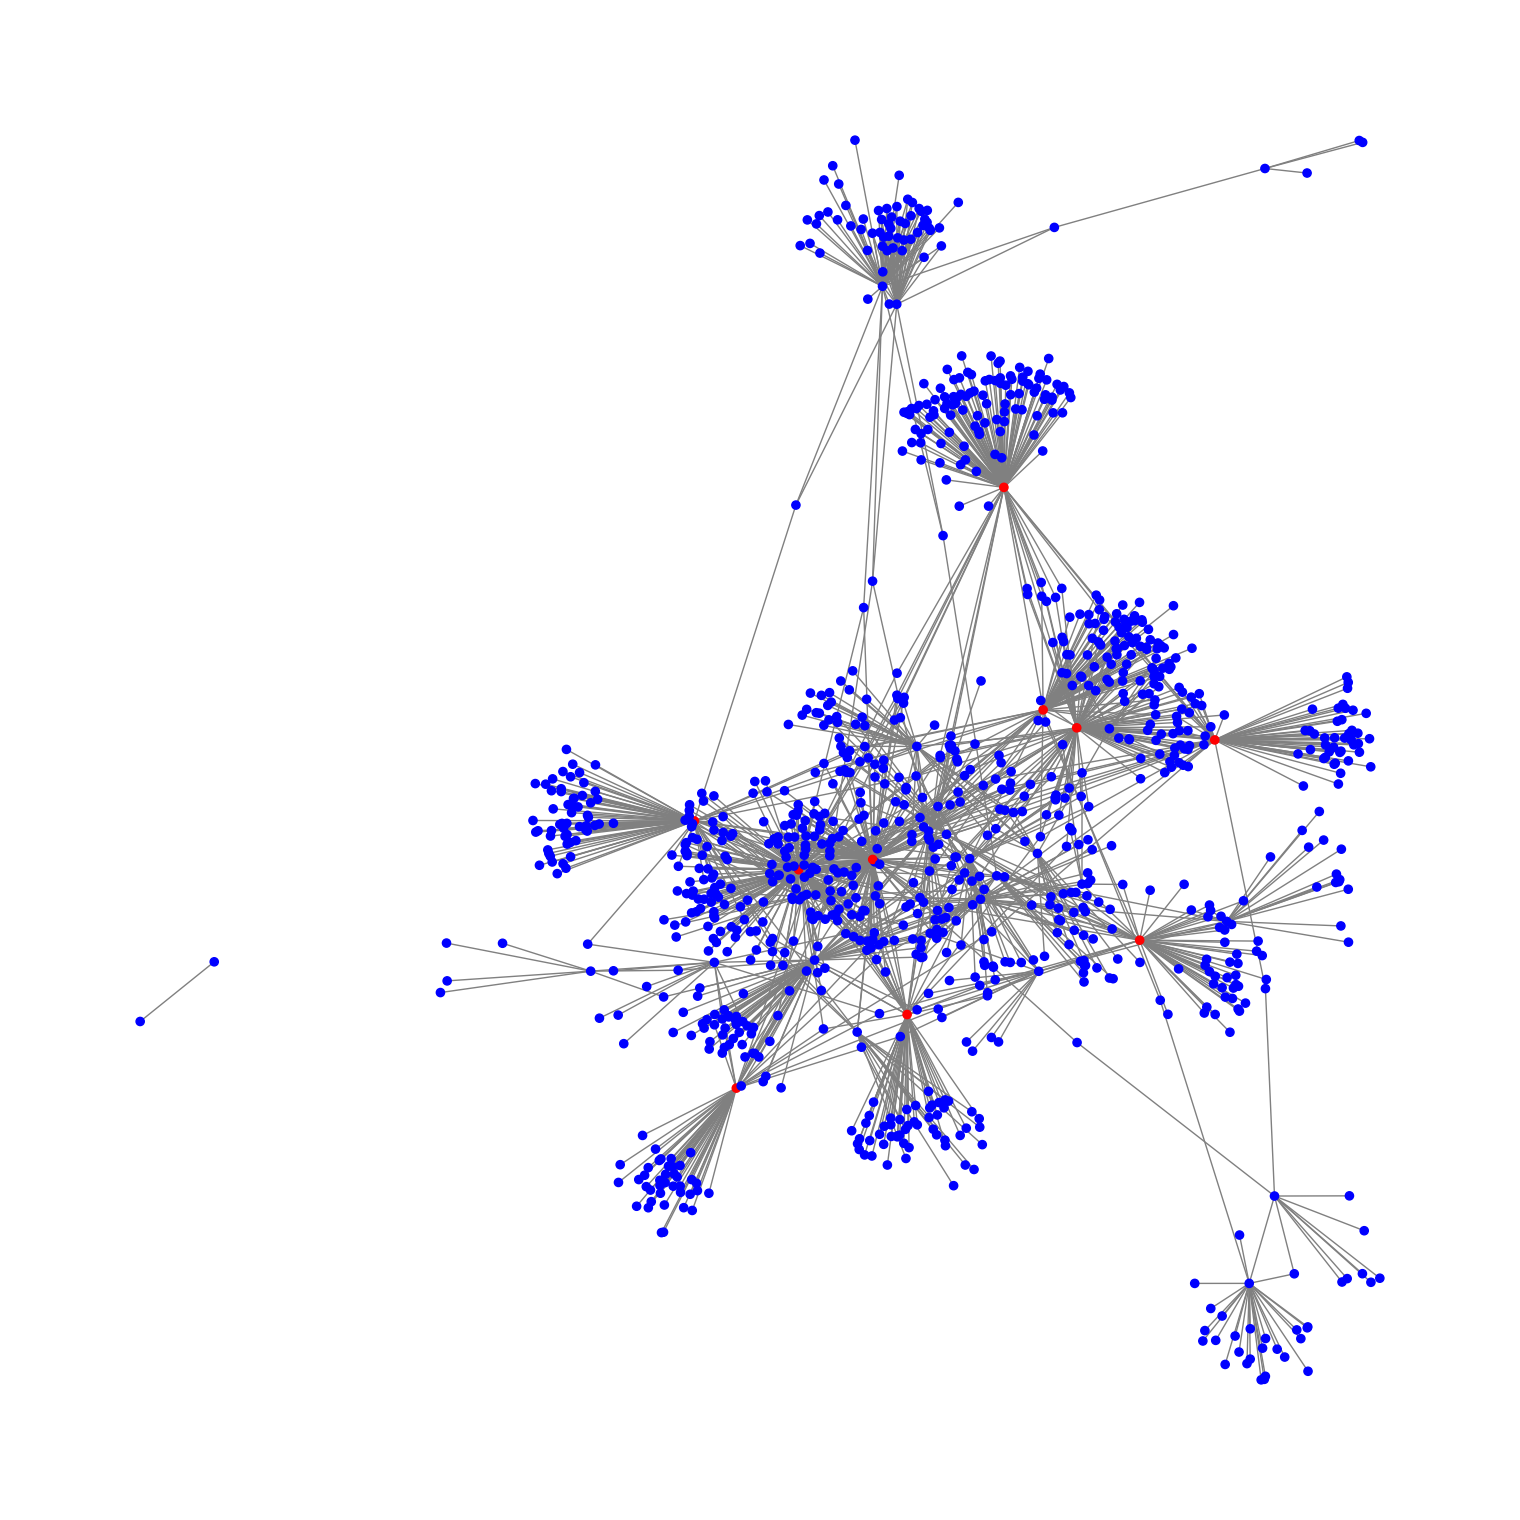

In [10]:
def ex1_4(graph=None):
    if graph is None:
        graph = ex1_1(num_maximum_edges=1500)
    graph = ex1_2(graph)
    graph = ex1_3(graph)

    anomaly_scores = [(node, graph.nodes[node]['anomaly_score']) for node in graph.nodes()]
    sorted_anomaly_scores = sorted(anomaly_scores, key=lambda x: x[1], reverse=True)

    TOP = 10
    print(f'Top {TOP} Anomaly Scores:')
    for node, anomaly_score in sorted_anomaly_scores[:TOP]:
        print(f'Node: {node} Anomaly Score: {anomaly_score}')

    anomaly_nodes = set(node for node, _ in sorted_anomaly_scores[:TOP])

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph, seed=23)

    node_colors = ['blue' if node not in anomaly_nodes else 'red' for node in graph.nodes()]

    nx.draw(graph, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)


ex1_4(graph=None)

Number of Nodes: 1103
Number of Edges: 1458
Linear Regression: C=1.048496696618426 theta=1.171943994843814
Top 10 Anomaly Scores:
Node: 5412 Anomaly Score: 1.0969583269668333
Node: 92357 Anomaly Score: 1.0628142484663246
Node: 126916 Anomaly Score: 1.0000000001482487
Node: 84424 Anomaly Score: 0.7799365054748489
Node: 94138 Anomaly Score: 0.7741022326734927
Node: 106274 Anomaly Score: 0.7415865203174368
Node: 127393 Anomaly Score: 0.677626206437839
Node: 75607 Anomaly Score: 0.6233939810084339
Node: 13353 Anomaly Score: 0.5950111297429825
Node: 60471 Anomaly Score: 0.5860460045303861


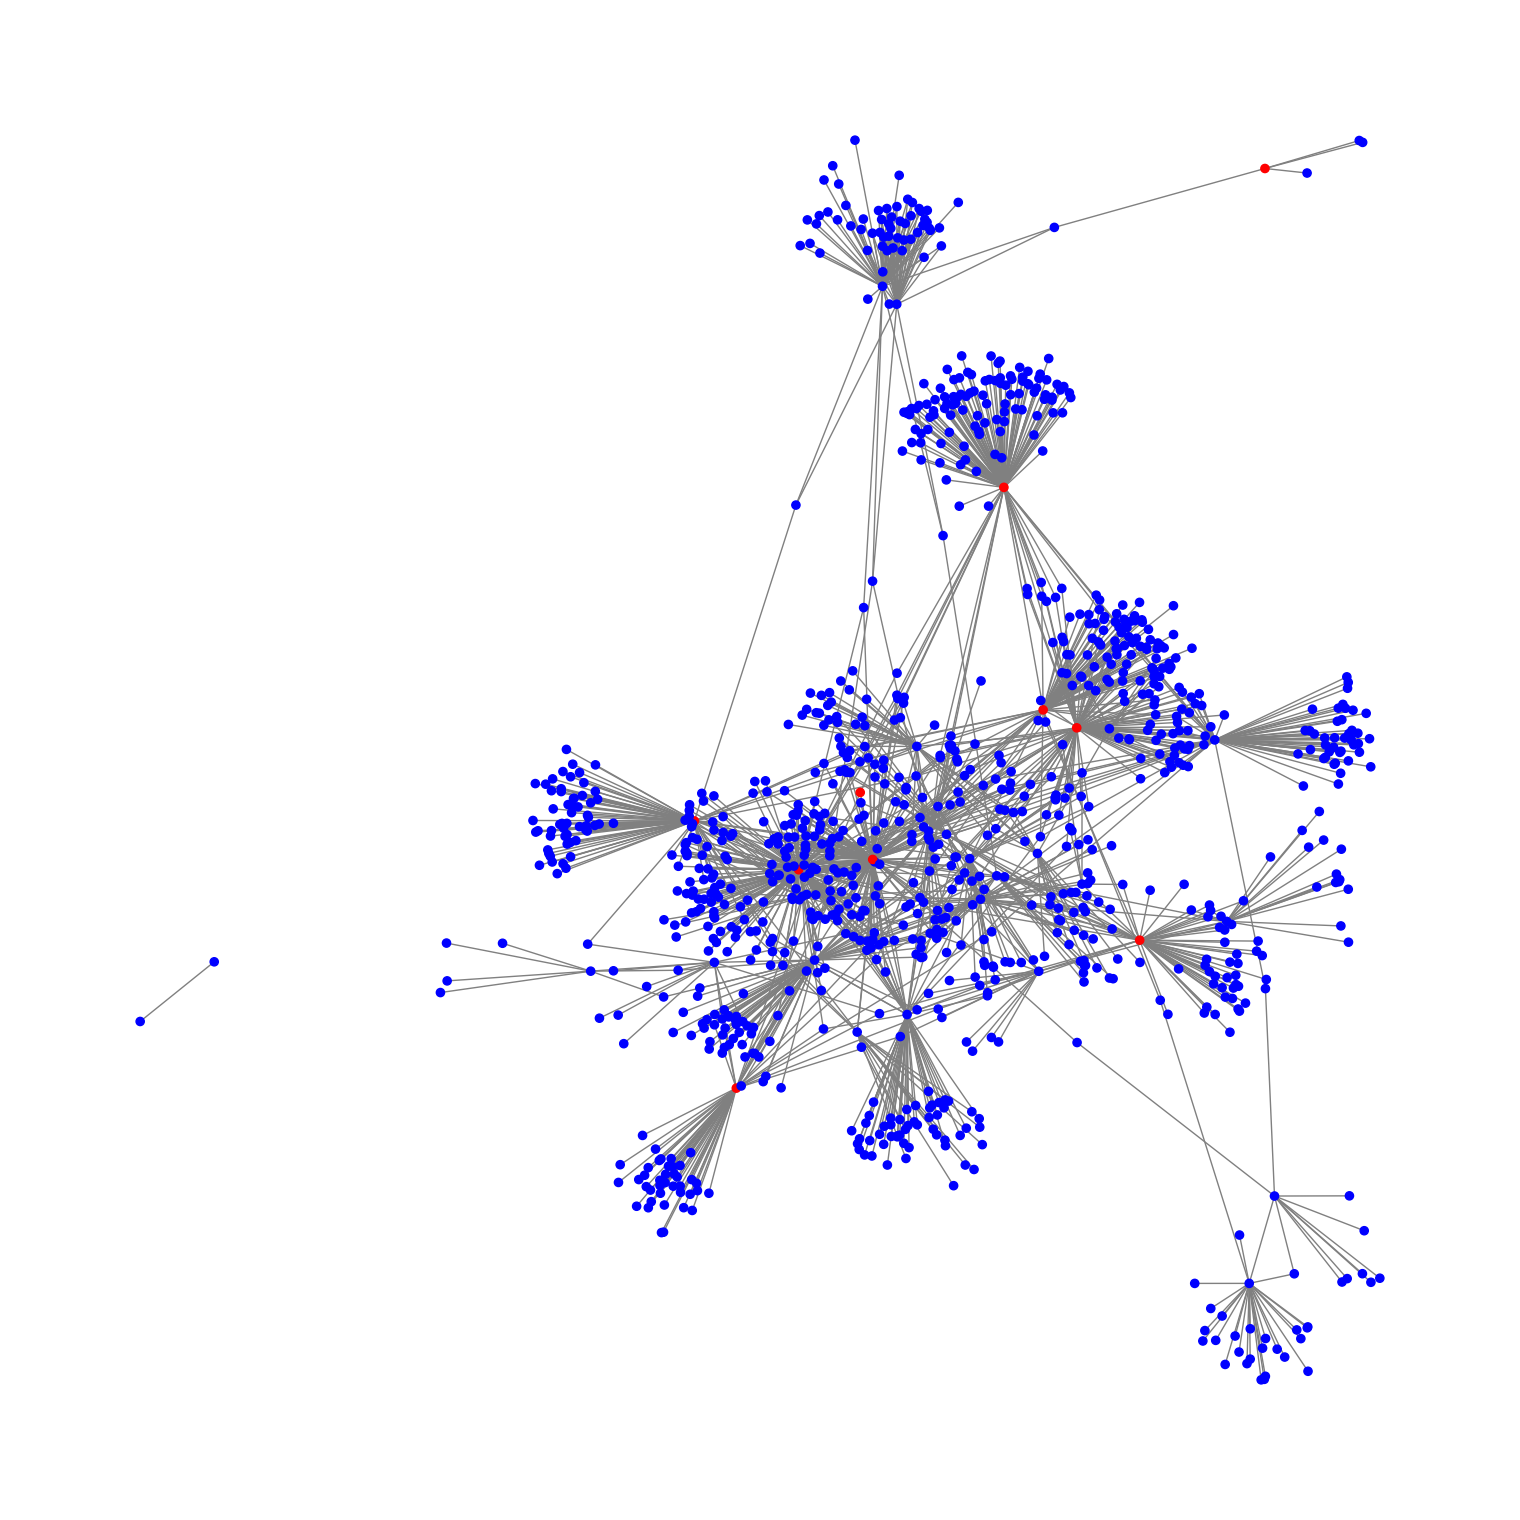

In [11]:
def ex1_5(graph=None):
    if graph is None:
        graph = ex1_1(num_maximum_edges=1500)
    graph = ex1_2(graph)
    graph = ex1_3(graph)

    old_anomaly_scores = np.array([graph.nodes[node]['anomaly_score'] for node in graph.nodes()])
    min_max_scaler = MinMaxScaler()
    min_max_scaler.fit(old_anomaly_scores.reshape(-1, 1))

    for node in graph.nodes():
        old_anomaly_score = graph.nodes[node]['anomaly_score']
        normalized_anomaly_score = min_max_scaler.transform(np.array(old_anomaly_score).reshape(1, 1))[0][0]
        graph.nodes[node]['anomaly_score'] = normalized_anomaly_score

    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])
    egonet_num_neighbors = np.array([graph.nodes[node]['egonet_num_neighbors'] for node in graph.nodes()])
    lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
    lof.fit(np.column_stack((egonet_num_edges, egonet_num_neighbors)))
    min_max_scaler = MinMaxScaler()
    min_max_scaler.fit(-lof.negative_outlier_factor_.reshape(-1, 1))
    normalized_negative_outlier_factors = min_max_scaler.transform(-lof.negative_outlier_factor_.reshape(-1, 1)).flatten()
    for idx, node in enumerate(graph.nodes()):
        graph.nodes[node]['anomaly_score'] += normalized_negative_outlier_factors[idx]

    anomaly_scores = [(node, graph.nodes[node]['anomaly_score']) for node in graph.nodes()]
    sorted_anomaly_scores = sorted(anomaly_scores, key=lambda x: x[1], reverse=True)

    TOP = 10
    print(f'Top {TOP} Anomaly Scores:')
    for node, anomaly_score in sorted_anomaly_scores[:TOP]:
        print(f'Node: {node} Anomaly Score: {anomaly_score}')

    anomaly_nodes = set(node for node, _ in sorted_anomaly_scores[:TOP])

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph, seed=23)

    node_colors = ['blue' if node not in anomaly_nodes else 'red' for node in graph.nodes()]

    nx.draw(graph, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)


ex1_5(graph=None)

### Exercise 2

Linear Regression: C=0.24885397945039034 theta=2.2466163422106242
Top 10 Anomaly Scores:
Node: clique-139 Anomaly Score: 4.565249201312653
Node: clique-40 Anomaly Score: 4.329125662804963
Node: clique-19 Anomaly Score: 3.251124819619824
Node: clique-27 Anomaly Score: 3.251124819619824
Node: clique-39 Anomaly Score: 3.251124819619824
Node: clique-43 Anomaly Score: 3.251124819619824
Node: clique-59 Anomaly Score: 3.251124819619824
Node: clique-79 Anomaly Score: 3.251124819619824
Node: clique-83 Anomaly Score: 3.251124819619824
Node: clique-91 Anomaly Score: 3.251124819619824
Linear Regression: C=0.24885397945039034 theta=2.2466163422106242
Top 10 Anomaly Scores:
Node: clique-40 Anomaly Score: 1.9475572981676224
Node: clique-0 Anomaly Score: 1.630592920506638
Node: clique-20 Anomaly Score: 1.630592920506638
Node: clique-60 Anomaly Score: 1.630592920506638
Node: clique-80 Anomaly Score: 1.630592920506638
Node: clique-81 Anomaly Score: 1.630592920506638
Node: clique-100 Anomaly Score: 1.630

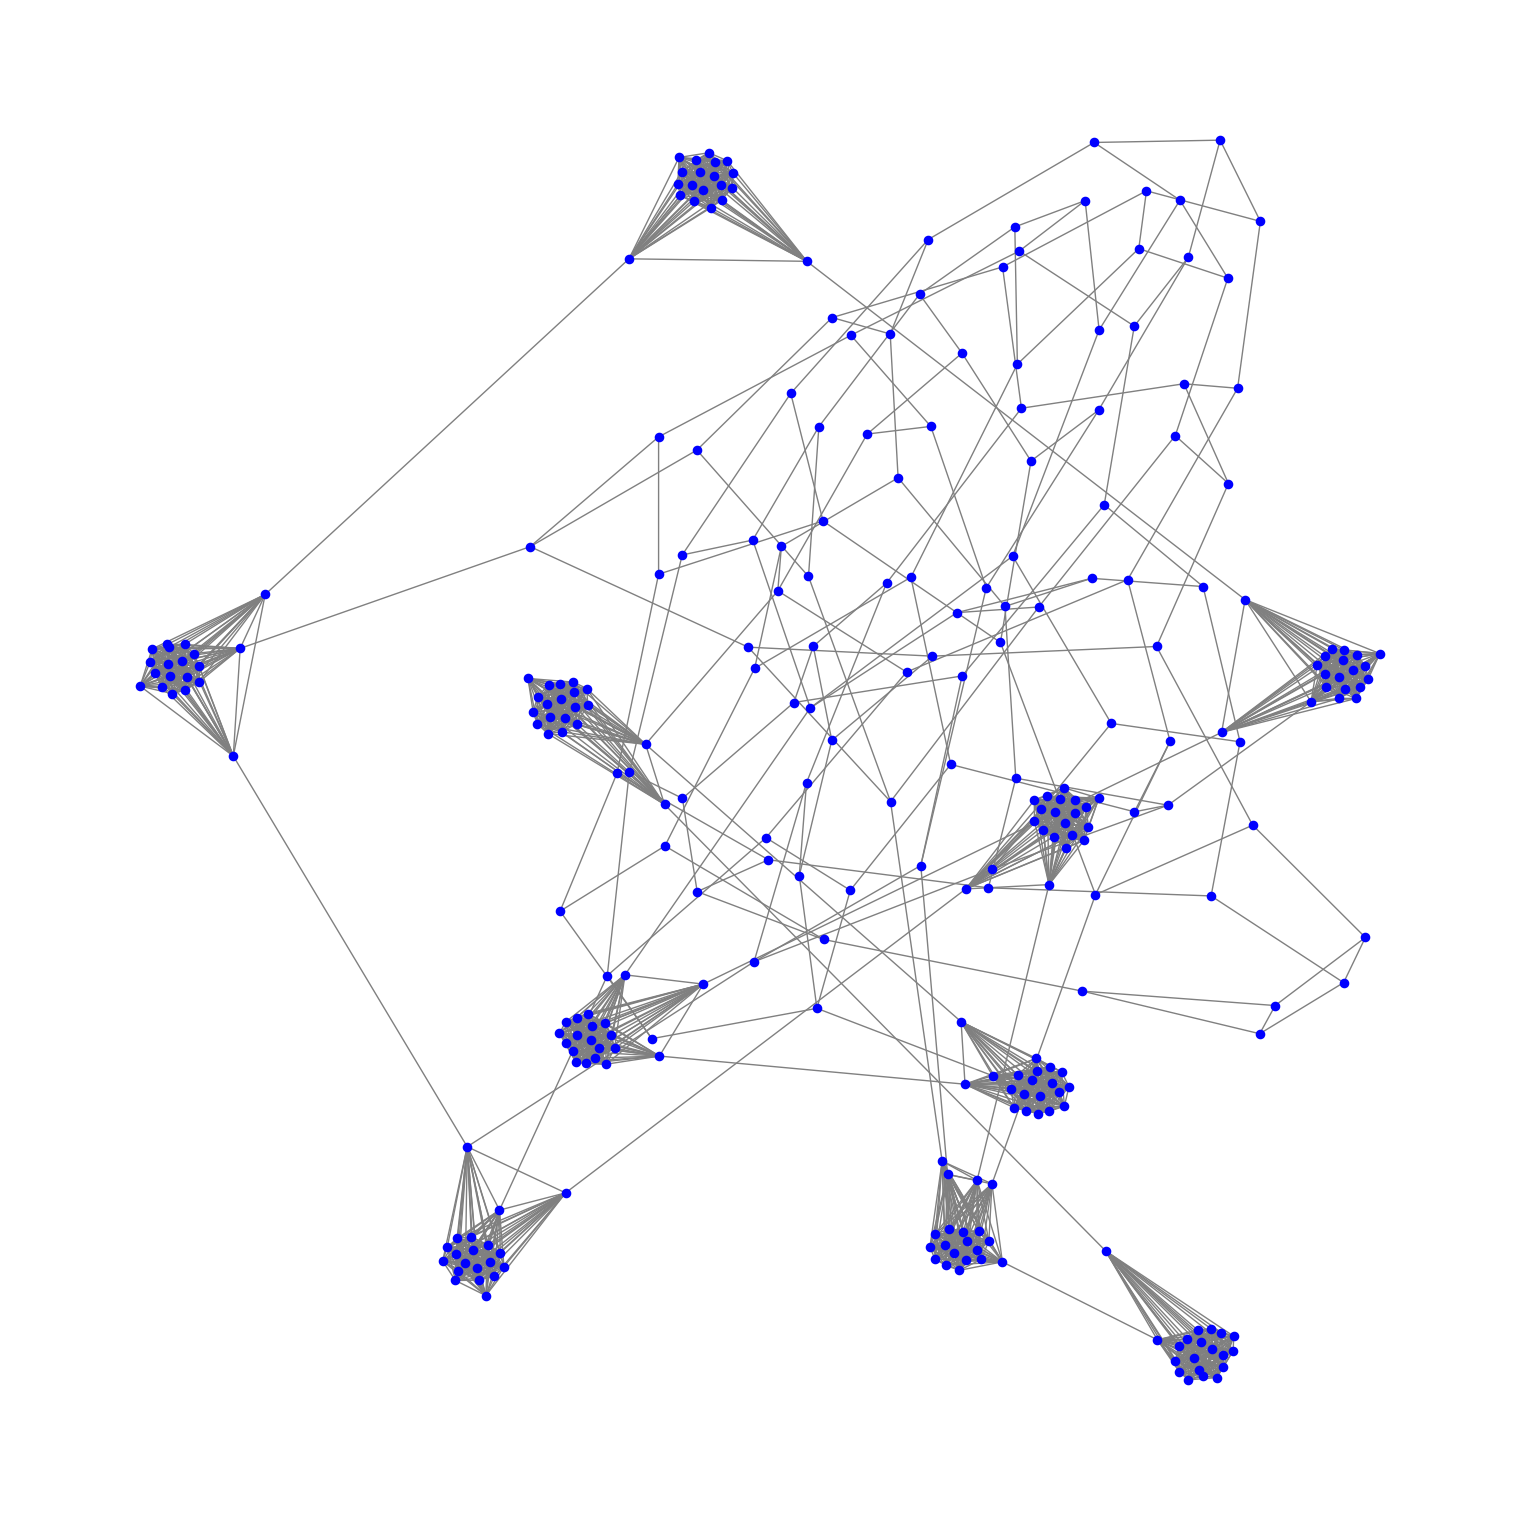

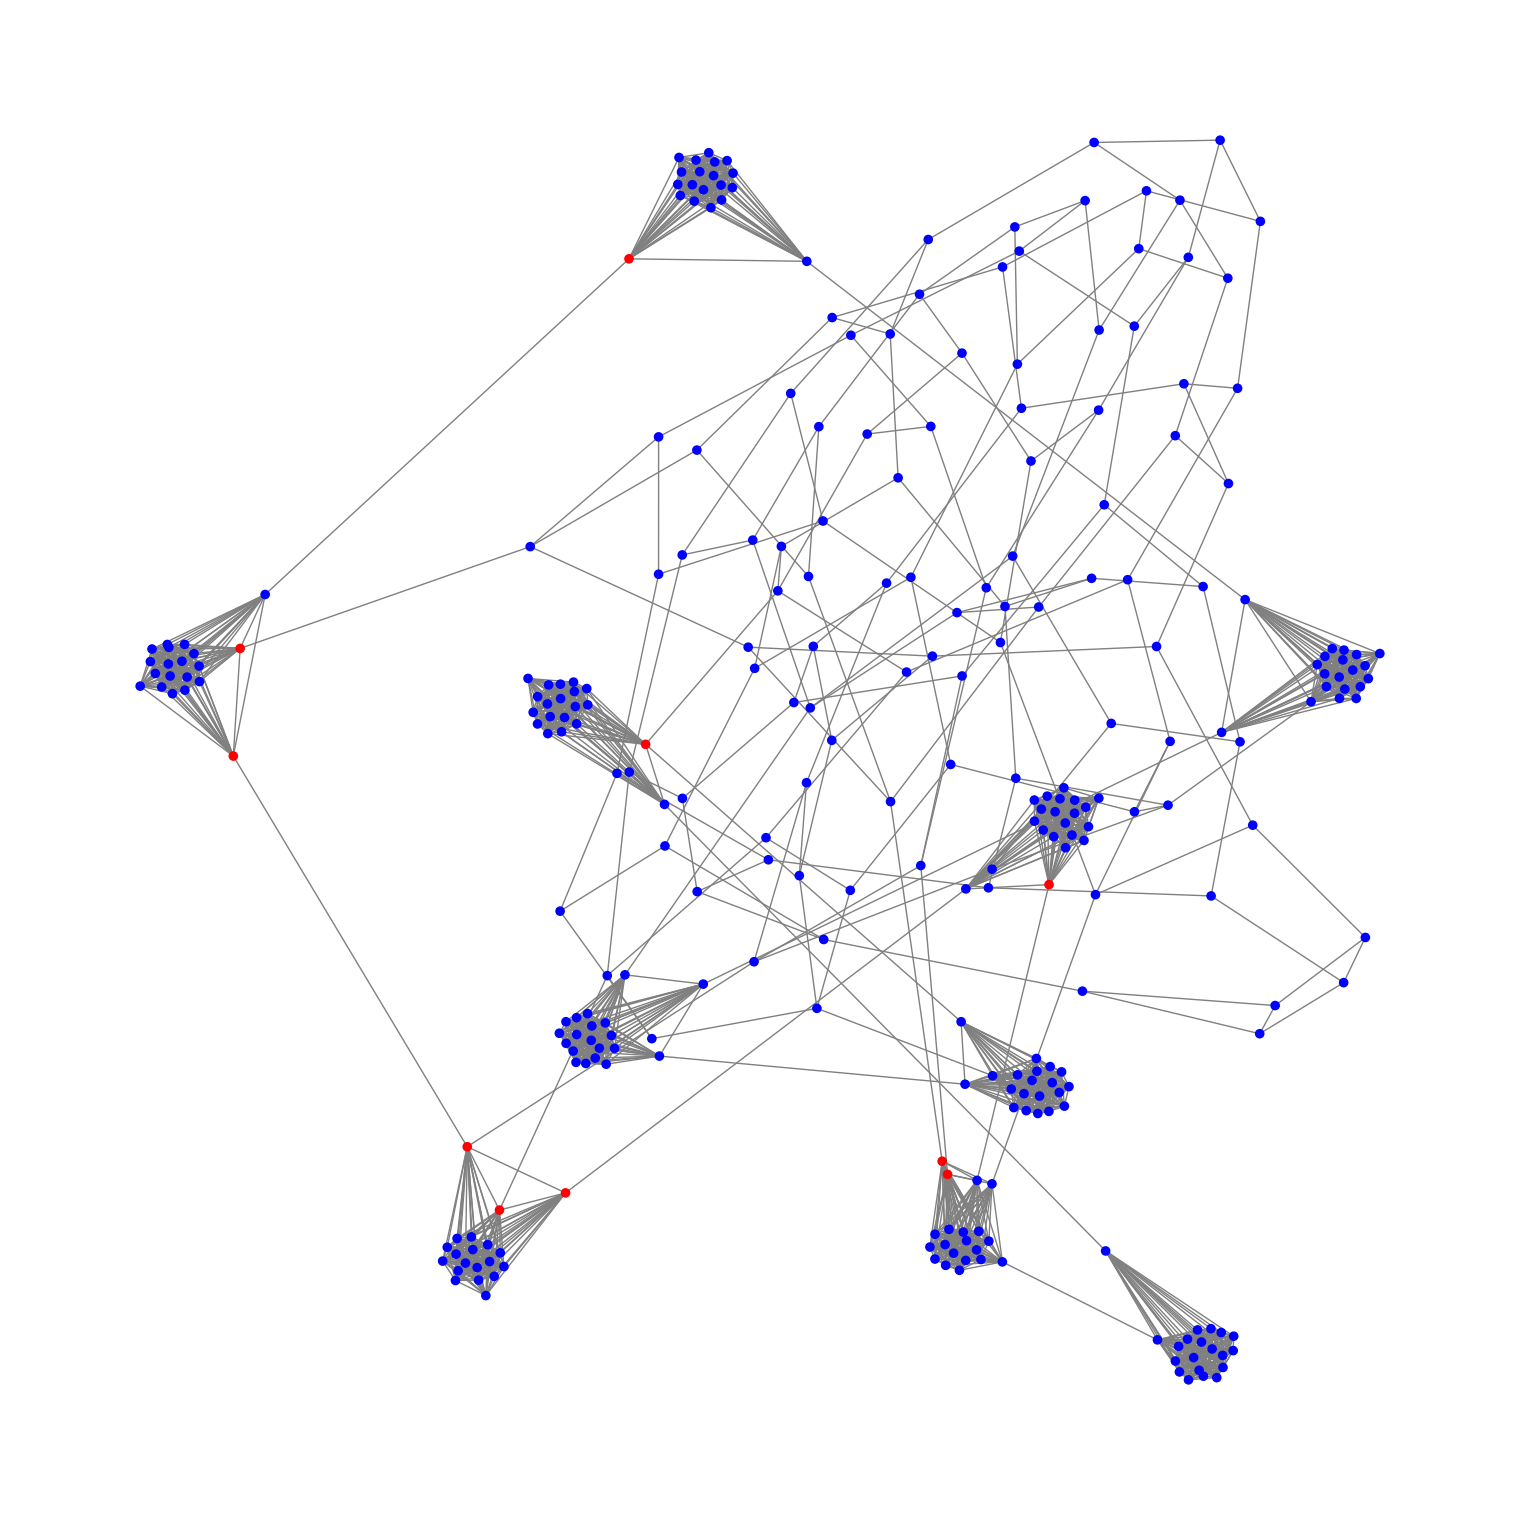

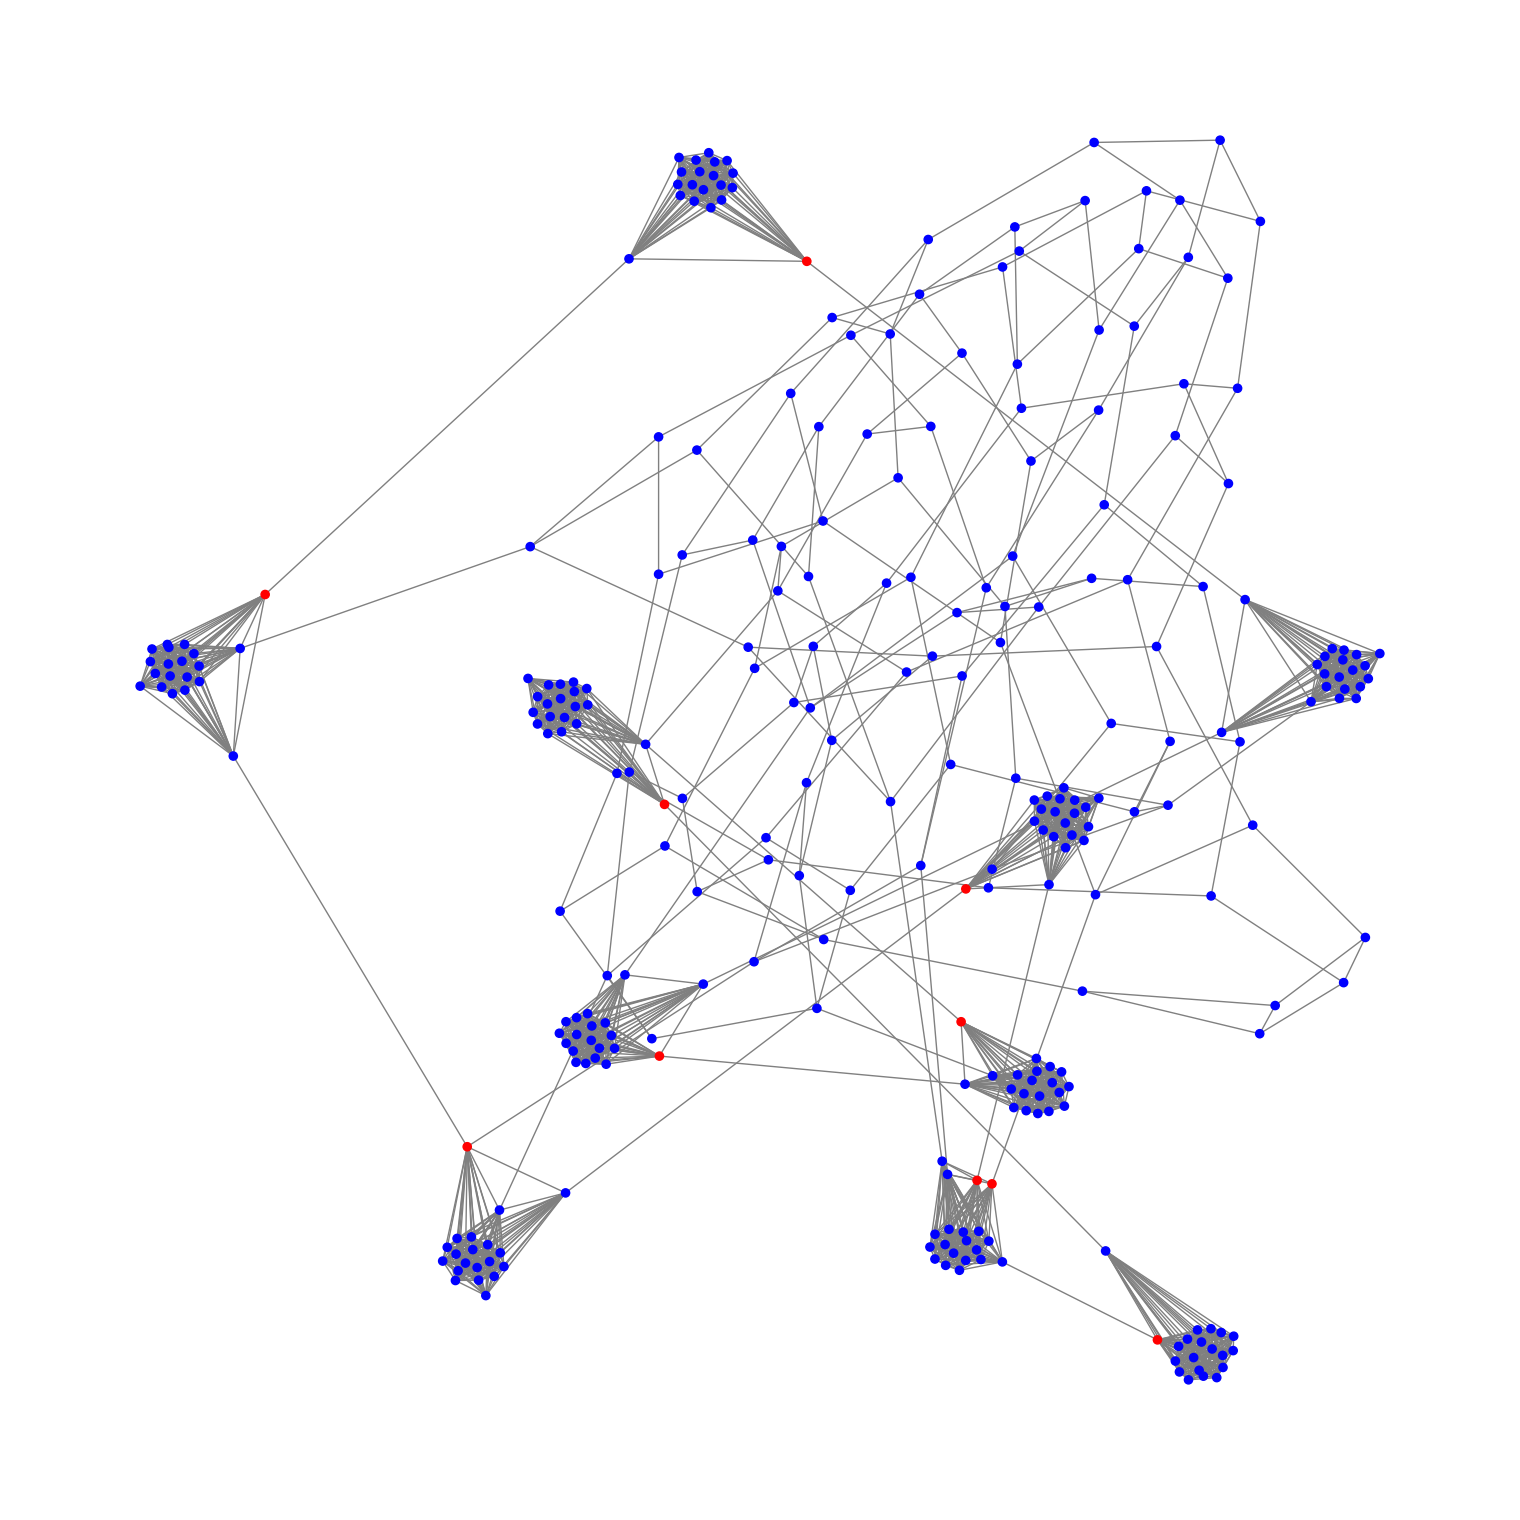

In [12]:
def ex2_1():
    graph_0 = nx.random_regular_graph(d=3, n=100)
    graph_1 = nx.connected_caveman_graph(l=10, k=20)

    graph_union = nx.union(graph_0, graph_1, rename=('regular-', 'clique-'))

    NUM_RANDOM_EDGES = 10
    nodes_graph_0 = list(graph_0.nodes())
    nodes_graph_1 = list(graph_1.nodes())
    random_nodes_0 = np.random.choice(nodes_graph_0, size=NUM_RANDOM_EDGES, replace=False)
    random_nodes_1 = np.random.choice(nodes_graph_1, size=NUM_RANDOM_EDGES, replace=False)
    for node_0, node_1 in zip(random_nodes_0, random_nodes_1):
        graph_union.add_edge(f'regular-{node_0}', f'clique-{node_1}')

    nx.set_edge_attributes(graph_union, 1, 'weight')

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph_union, seed=23)

    nx.draw(graph_union, pos=positions, node_color='blue', edge_color='gray', node_size=35)

    ex1_4(graph=copy.deepcopy(graph_union))
    ex1_5(graph=copy.deepcopy(graph_union))


ex2_1()

In [13]:
def ex2_anomaly_scores(graph):

    nodes = np.array(list(graph.nodes()))
    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])
    egonet_total_weights = np.array([graph.nodes[node]['egonet_total_weight'] for node in graph.nodes()])

    filter_mask = ((0 < egonet_num_edges) & (0 < egonet_total_weights))
    nodes = nodes[filter_mask]
    egonet_num_edges = egonet_num_edges[filter_mask]
    egonet_total_weights = egonet_total_weights[filter_mask]

    X = np.log(egonet_num_edges).reshape(-1, 1)
    Y = np.log(egonet_total_weights).reshape(-1, 1)

    linear_regression = LinearRegression()
    linear_regression.fit(X, Y)

    C = np.exp(linear_regression.intercept_[0])
    theta = linear_regression.coef_[0][0]

    print(f'Linear Regression: C={C} theta={theta}')

    egonet_total_weights_pred = C * (egonet_num_edges ** theta)

    for idx, node in enumerate(nodes):
        numerator = max(egonet_total_weights[idx], egonet_total_weights_pred[idx])
        denominator = min(egonet_total_weights[idx], egonet_total_weights_pred[idx])
        logarithm = np.log(np.abs(egonet_total_weights[idx] - egonet_total_weights_pred[idx]) + 1.0)

        anomaly_score = (numerator / denominator) * logarithm
        graph.nodes[node]['anomaly_score'] = anomaly_score

    for node in graph.nodes():
        if node not in nodes:
            graph.nodes[node]['anomaly_score'] = 0.0

    # Local Outlier Factor

    old_anomaly_scores = np.array([graph.nodes[node]['anomaly_score'] for node in graph.nodes()])
    min_max_scaler = MinMaxScaler()
    min_max_scaler.fit(old_anomaly_scores.reshape(-1, 1))

    for node in graph.nodes():
        old_anomaly_score = graph.nodes[node]['anomaly_score']
        normalized_anomaly_score = min_max_scaler.transform(np.array(old_anomaly_score).reshape(1, 1))[0][0]
        graph.nodes[node]['anomaly_score'] = normalized_anomaly_score

    egonet_total_weights = np.array([graph.nodes[node]['egonet_total_weight'] for node in graph.nodes()])
    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])
    lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
    lof.fit(np.column_stack((egonet_total_weights, egonet_num_edges)))
    min_max_scaler = MinMaxScaler()
    min_max_scaler.fit(-lof.negative_outlier_factor_.reshape(-1, 1))
    normalized_negative_outlier_factors = min_max_scaler.transform(-lof.negative_outlier_factor_.reshape(-1, 1)).flatten()
    for idx, node in enumerate(graph.nodes()):
        graph.nodes[node]['anomaly_score'] += normalized_negative_outlier_factors[idx]

    return graph

Selected Nodes for Heavy Vicinity: regular_0-52 regular_1-54
Egonet Node 0 Edges: [('regular_0-26', 'regular_0-52'), (np.str_('regular_0-52'), 'regular_0-94'), (np.str_('regular_0-52'), 'regular_0-82')]
Egonet Node 1 Edges: [('regular_1-63', 'regular_1-54'), ('regular_1-75', 'regular_1-54'), (np.str_('regular_1-54'), 'regular_1-48'), (np.str_('regular_1-54'), 'regular_1-50'), (np.str_('regular_1-54'), 'regular_1-55')]
Linear Regression: C=1.0863028361410367 theta=0.9926221889033866
Top 4 Anomaly Scores:
Node: regular_1-54 Anomaly Score: 1.9999999999999998
Node: regular_0-52 Anomaly Score: 1.424187016295917
Node: regular_0-26 Anomaly Score: 0.5293036329432663
Node: regular_0-94 Anomaly Score: 0.5293036329432663


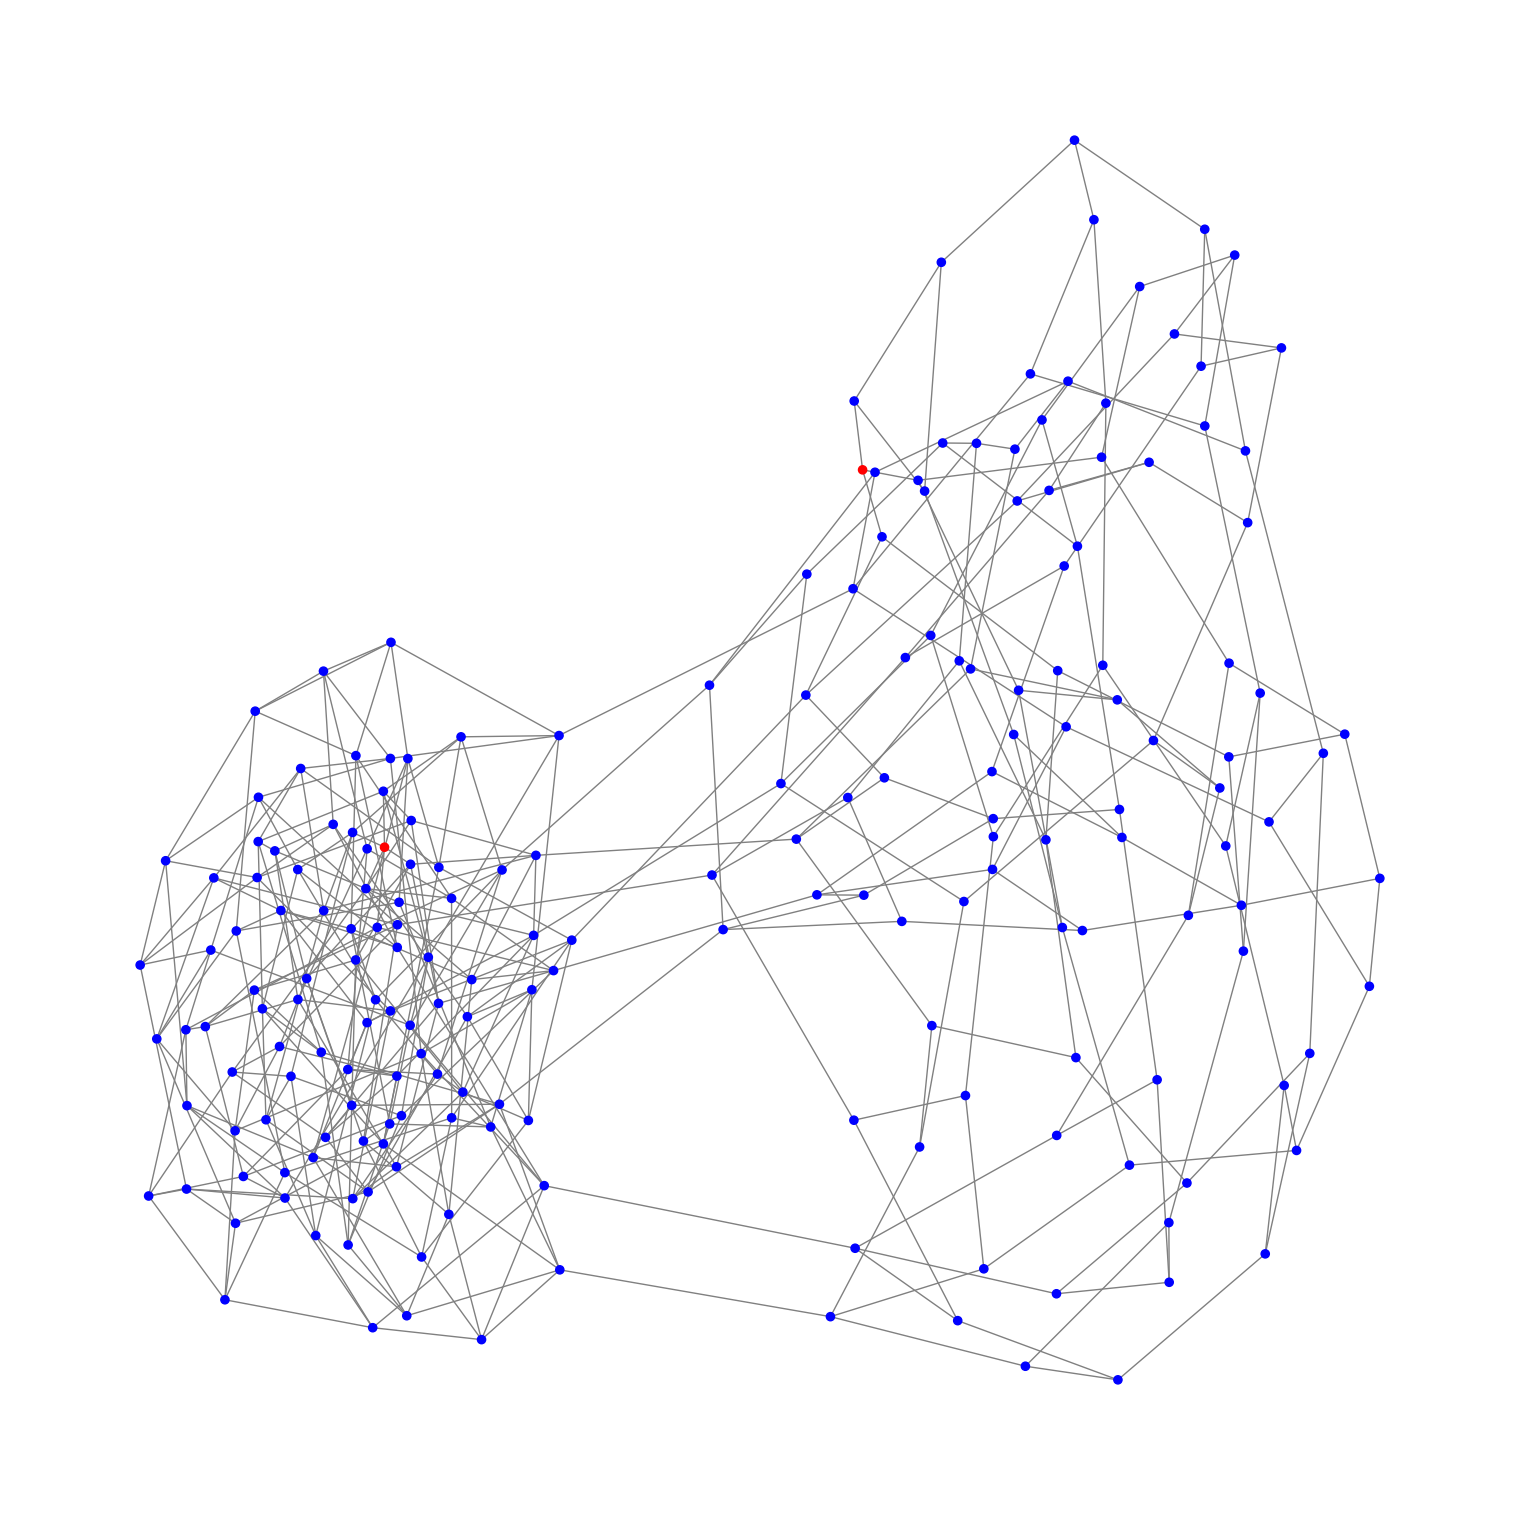

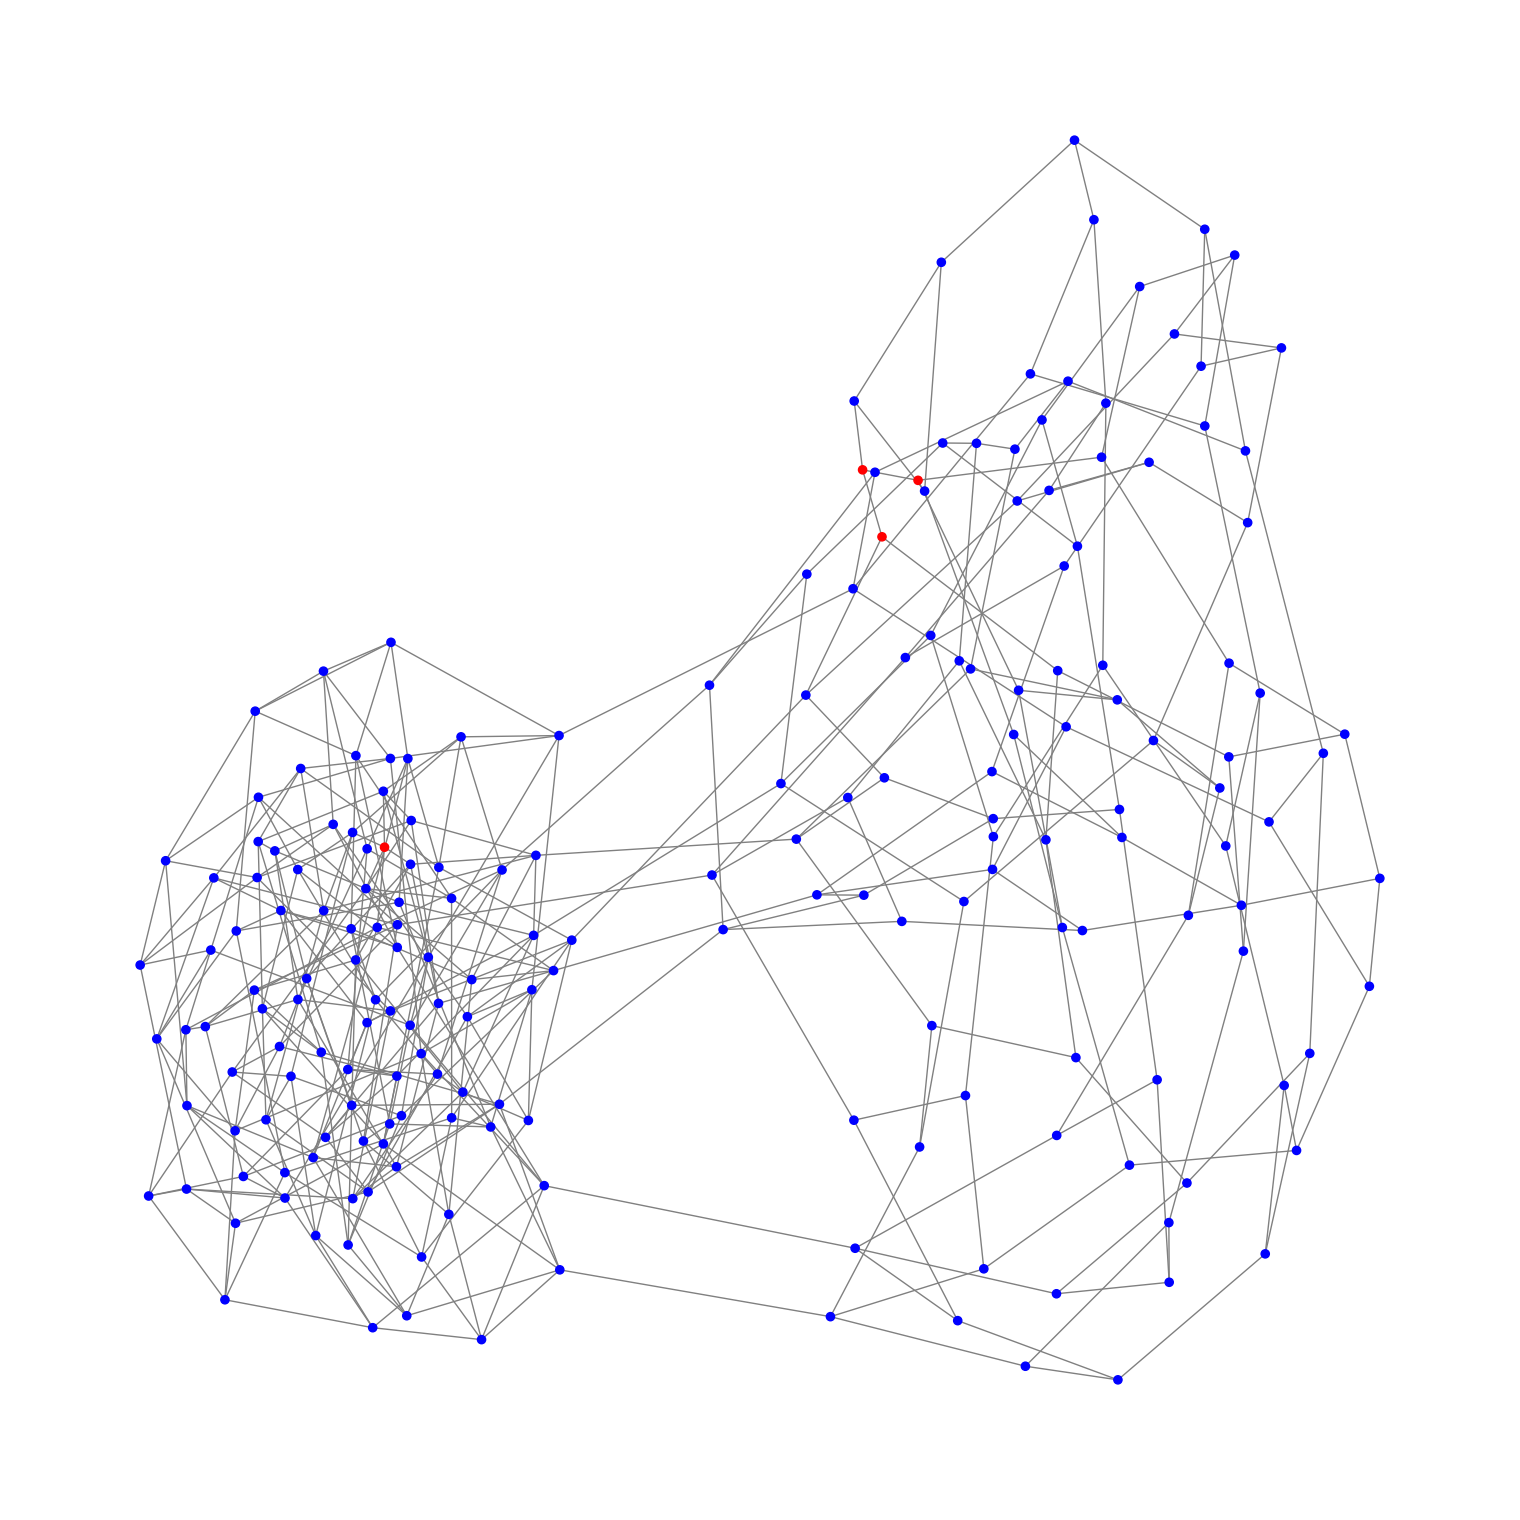

In [14]:
def ex2_2():
    graph_0 = nx.random_regular_graph(d=3, n=100)
    graph_1 = nx.random_regular_graph(d=5, n=100)

    graph_union = nx.union(graph_0, graph_1, rename=('regular_0-', 'regular_1-'))
    
    ### pentru a avea o singura componenta conexa
    NUM_RANDOM_EDGES = 10
    nodes_graph_0 = list(graph_0.nodes())
    nodes_graph_1 = list(graph_1.nodes())
    random_nodes_0 = np.random.choice(nodes_graph_0, size=NUM_RANDOM_EDGES, replace=False)
    random_nodes_1 = np.random.choice(nodes_graph_1, size=NUM_RANDOM_EDGES, replace=False)
    for node_0, node_1 in zip(random_nodes_0, random_nodes_1):
        graph_union.add_edge(f'regular_0-{node_0}', f'regular_1-{node_1}')
    ###

    for edge in graph_union.edges():
        graph_union.add_edge(edge[0], edge[1], weight=1)

    random_node_0, random_node_1 = np.random.choice(list(graph_union.nodes()), size=2, replace=False)
    neighbors_node_0 = list(graph_union.neighbors(random_node_0))
    egonet_node_0 = graph_union.subgraph([random_node_0] + neighbors_node_0)
    for egonet_edge in egonet_node_0.edges():
        graph_union[egonet_edge[0]][egonet_edge[1]]['weight'] += 10

    neighbors_node_1 = list(graph_union.neighbors(random_node_1))
    egonet_node_1 = graph_union.subgraph([random_node_1] + neighbors_node_1)
    for egonet_edge in egonet_node_1.edges():
        graph_union[egonet_edge[0]][egonet_edge[1]]['weight'] += 10

    print(f'Selected Nodes for Heavy Vicinity: {random_node_0} {random_node_1}')
    print(f'Egonet Node 0 Edges: {egonet_node_0.edges()}')
    print(f'Egonet Node 1 Edges: {egonet_node_1.edges()}')

    node_colors = ['red' if (node == random_node_0 or node == random_node_1)
                   else 'blue' for node in graph_union.nodes()]

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph_union, seed=23)

    nx.draw(graph_union, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)

    graph_union = ex1_2(graph_union)
    graph_union = ex2_anomaly_scores(graph_union)

    anomaly_scores = [(node, graph_union.nodes[node]['anomaly_score']) for node in graph_union.nodes()]
    sorted_anomaly_scores = sorted(anomaly_scores, key=lambda x: x[1], reverse=True)

    TOP = 4
    print(f'Top {TOP} Anomaly Scores:')
    for node, anomaly_score in sorted_anomaly_scores[:TOP]:
        print(f'Node: {node} Anomaly Score: {anomaly_score}')

    anomaly_nodes = set(node for node, _ in sorted_anomaly_scores[:TOP])

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph_union, seed=23)

    node_colors = ['blue' if node not in anomaly_nodes else 'red' for node in graph_union.nodes()]

    nx.draw(graph_union, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)


ex2_2()

### Exercise 3

In [15]:
def ex3_2():
    acm_mat = loadmat('ACM.mat')
    
    node_attributes = acm_mat['Attributes']
    adjacency_matrix = acm_mat['Network']
    labels = acm_mat['Label']
    
    edges, edge_weights = from_scipy_sparse_matrix(adjacency_matrix)
    
    return edges, edge_weights, node_attributes, labels, adjacency_matrix
    
    
edges_ex3_2, edge_weights_ex3_2, node_attributes_ex3_2, labels_ex3_2, adjacency_matrix_ex3_2 = ex3_2()

In [16]:
class GraphEncoder(torch.nn.Module):
    def __init__(self, num_features):
        super(GraphEncoder, self).__init__()
        
        self.gcn_conv_0 = torch_geometric.nn.GCNConv(in_channels=num_features, out_channels=128)
        self.relu_0 = torch.nn.ReLU()
        
        self.gcn_conv_1 = torch_geometric.nn.GCNConv(in_channels=128, out_channels=64)
        self.relu_1 = torch.nn.ReLU()
        
    def forward(self, node_attributes, edges):
        X = self.gcn_conv_0(node_attributes, edges)
        X = self.relu_0(X)
        
        X = self.gcn_conv_1(X, edges)
        X = self.relu_1(X)
        
        return X
    
    
class AttributeDecoder(torch.nn.Module):
    def __init__(self, num_features):
        super(AttributeDecoder, self).__init__()
        
        self.gcn_conv_0 = torch_geometric.nn.GCNConv(in_channels=64, out_channels=128)
        self.relu_0 = torch.nn.ReLU()
        
        self.gcn_conv_1 = torch_geometric.nn.GCNConv(in_channels=128, out_channels=num_features)
        self.relu_1 = torch.nn.ReLU()
        
    def forward(self, latent_representations, edges):
        X = self.gcn_conv_0(latent_representations, edges)
        X = self.relu_0(X)
        
        X = self.gcn_conv_1(X, edges)
        X = self.relu_1(X)
        
        return X
    
    
class StructureDecoder(torch.nn.Module):
    def __init__(self):
        super(StructureDecoder, self).__init__()
        
        self.gcn_conv_0 = torch_geometric.nn.GCNConv(in_channels=64, out_channels=64)
        self.relu_0 = torch.nn.ReLU()
        
    def forward(self, latent_representations, edges):
        X = self.gcn_conv_0(latent_representations, edges)
        X = self.relu_0(X)
        
        adjacency_matrix = X @ X.T
        
        return adjacency_matrix
        

class GraphAutoEncoder(torch.nn.Module):
    def __init__(self, num_features):
        super(GraphAutoEncoder, self).__init__()
        
        self.encoder = GraphEncoder(num_features=num_features)
        self.attribute_decoder = AttributeDecoder(num_features=num_features)
        self.structure_decoder = StructureDecoder()
        
    def forward(self, node_attributes, edges):
        latent_representations = self.encoder(node_attributes, edges)
        
        reconstructed_node_attributes = self.attribute_decoder(latent_representations, edges)
        reconstructed_adjacency_matrix = self.structure_decoder(latent_representations, edges)
        
        return reconstructed_node_attributes, reconstructed_adjacency_matrix

In [17]:
# functia de loss
def ex3_4(node_attributes, reconstructed_node_attributes, adjacency_matrix, reconstructed_adjacency_matrix, alpha=0.8):
    node_attributes_loss = torch.norm(node_attributes - reconstructed_node_attributes, p='fro') ** 2
    adjacency_matrix_loss = torch.norm(adjacency_matrix - reconstructed_adjacency_matrix, p='fro') ** 2
    
    total_loss = alpha * node_attributes_loss + (1.0 - alpha) * adjacency_matrix_loss
    return total_loss

Epoch 1/20 Loss: 39768.45703125
Epoch 2/20 Loss: 122468.8671875
Epoch 3/20 Loss: 39478.62890625
Epoch 4/20 Loss: 39713.4296875
Epoch 5/20 Loss: 39734.41015625 ROC AUC Score: 0.7995363823165259
Epoch 6/20 Loss: 39725.23828125
Epoch 7/20 Loss: 39692.46875
Epoch 8/20 Loss: 39663.29296875
Epoch 9/20 Loss: 39673.28125
Epoch 10/20 Loss: 39689.26171875 ROC AUC Score: 0.799556204049559
Epoch 11/20 Loss: 39693.984375
Epoch 12/20 Loss: 39686.4296875
Epoch 13/20 Loss: 39668.8203125
Epoch 14/20 Loss: 39648.6953125
Epoch 15/20 Loss: 39647.84375 ROC AUC Score: 0.7995633736125708
Epoch 16/20 Loss: 39663.06640625
Epoch 17/20 Loss: 39669.96875
Epoch 18/20 Loss: 39652.78125
Epoch 19/20 Loss: 39620.69921875
Epoch 20/20 Loss: 39618.99609375 ROC AUC Score: 0.7996338040256885


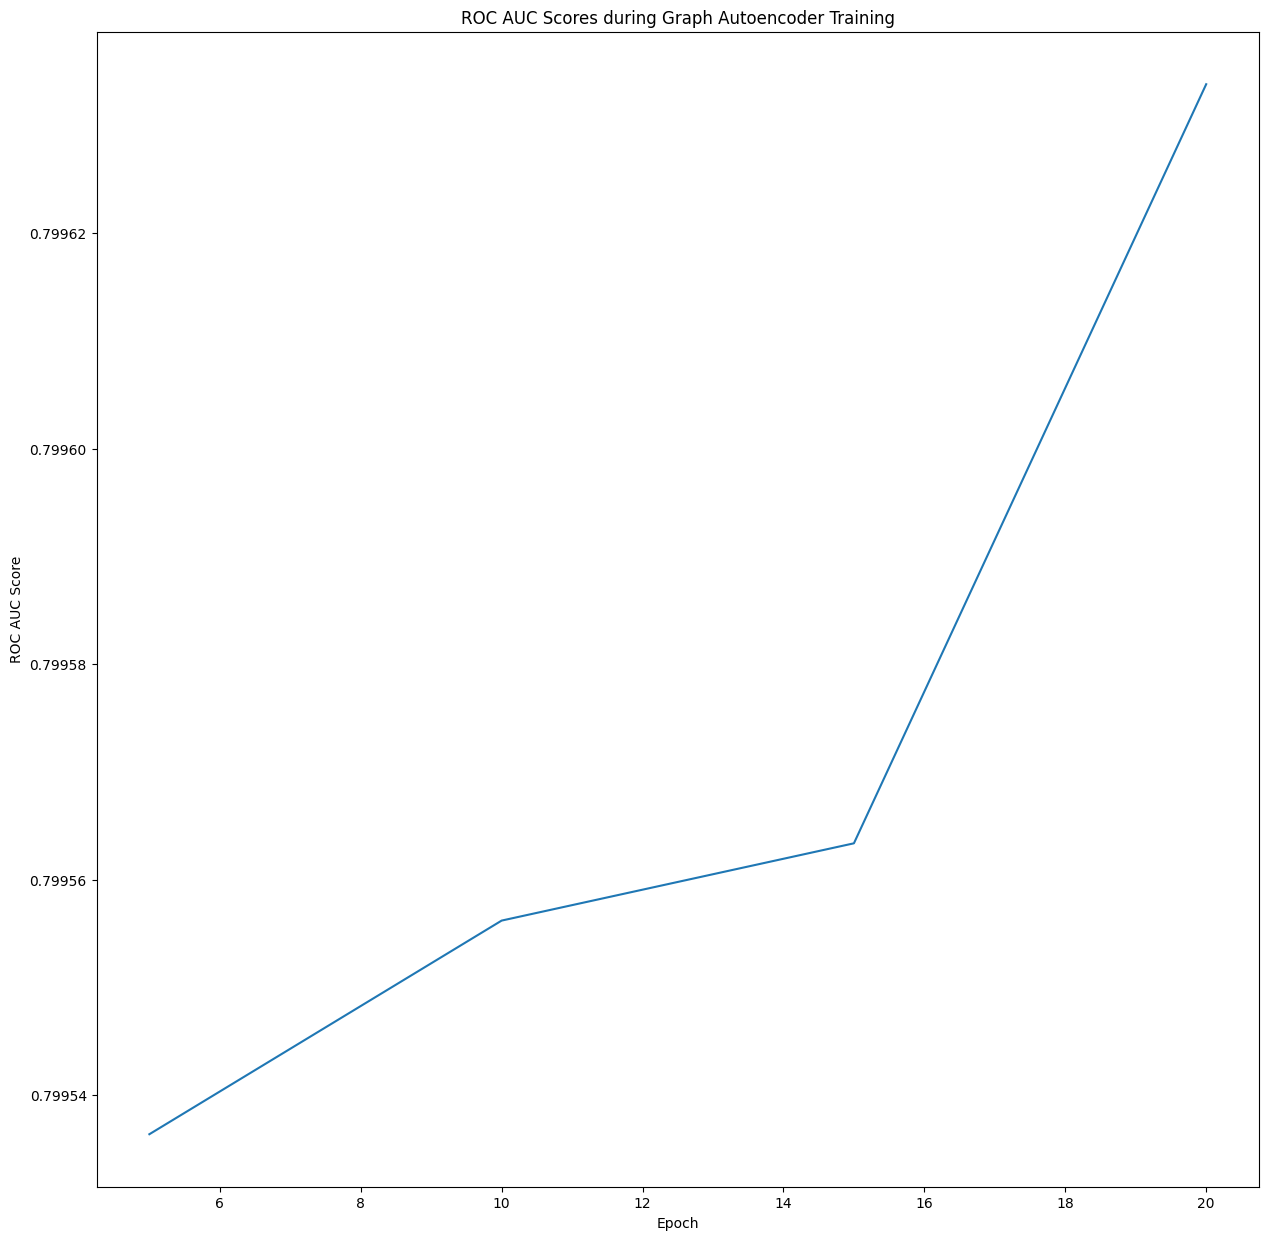

In [22]:
def ex3_5(node_attributes, edges, adjacency_matrix, labels):
    LEARNING_RATE = 0.004
    NUM_EPOCHS = 20
    
    model = GraphAutoEncoder(num_features=node_attributes.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    epochs = []
    roc_auc_scores = []
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        
        optimizer.zero_grad()
        
        reconstructed_node_attributes, reconstructed_adjacency_matrix = model(node_attributes, edges)
        
        loss = ex3_4(node_attributes, reconstructed_node_attributes, adjacency_matrix, reconstructed_adjacency_matrix)
        
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 5 == 0:       
            model.eval()
            
            with torch.no_grad():
                reconstructed_node_attributes, reconstructed_adjacency_matrix = model(node_attributes, edges)
                
                node_attributes_reconstruction_error = torch.norm(node_attributes - reconstructed_node_attributes, p='fro', dim=1)
                adjacency_matrix_reconstruction_error = torch.norm(adjacency_matrix - reconstructed_adjacency_matrix, p='fro', dim=1)
                
                combined_error = node_attributes_reconstruction_error + adjacency_matrix_reconstruction_error
                
                roc_auc = roc_auc_score(labels.numpy().flatten(), 
                                        (1.0 - torch.exp(-combined_error)).numpy().flatten())
                epochs.append(epoch + 1)
                roc_auc_scores.append(roc_auc)
                
                print(f'Epoch {epoch + 1}/{NUM_EPOCHS} Loss: {loss.item()} ROC AUC Score: {roc_auc}')
        else:
            print(f'Epoch {epoch + 1}/{NUM_EPOCHS} Loss: {loss.item()}')
            
    plt.figure(figsize=(15, 15))
    plt.plot(epochs, roc_auc_scores)
    plt.xlabel('Epoch')
    plt.ylabel('ROC AUC Score')
    plt.title('ROC AUC Scores during Graph Autoencoder Training')
    plt.show()
    
    return model


model_ex3_5 = ex3_5(torch.tensor(node_attributes_ex3_2.toarray(), dtype=torch.float32),
                    edges_ex3_2,
                    torch.tensor(adjacency_matrix_ex3_2.toarray(), dtype=torch.float32),
                    torch.tensor(labels_ex3_2, dtype=torch.float32))